# 🛍️ StockSense — Prévision de la Demande pour le Retail Mode

## Contexte du projet
Ce notebook constitue le cœur du projet StockSense, une solution de demand forecasting
développée dans le cadre d'une thèse RNCP Data Engineer.

**Problème métier :** Dans le secteur de la mode, les erreurs de prévision de la demande
coûtent cher dans les deux sens — les surstocks immobilisent du cash et génèrent des
démarques, tandis que les ruptures font perdre des ventes et dégradent l'expérience client.

**Solution :** Un modèle de Machine Learning entraîné sur l'historique de ventes réel
de 1 115 points de vente, capable de prévoir les ventes journalières par magasin avec
une précision mesurable.

**Dataset :** Rossmann Store Sales (Kaggle) — 2 ans d'historique, 1M+ transactions.
Recontextualisé comme enseigne de mode fictive "ModeCast Retail Group".

## Architecture du notebook
1. Chargement et exploration des données
2. Analyse exploratoire (EDA)
3. Feature Engineering
4. Entraînement du modèle XGBoost
5. Évaluation des performances
6. Sauvegarde du modèle pour déploiement API

## 📦 Étape 1 — Chargement des données

### Pourquoi cette étape ?
Avant tout modèle, il faut comprendre ce qu'on manipule. En demand planning industriel,
cette phase s'appelle la **data discovery** — on inventorie les sources disponibles,
leur structure, leur qualité, et leur complétude.

### Les deux sources de données
- **train.csv** : l'historique transactionnel — une ligne = un jour de ventes pour un magasin.
  C'est l'équivalent d'un extract de votre ERP (SAP, Oracle) ou de votre POS (caisse).
- **store.csv** : le référentiel magasin — caractéristiques fixes de chaque point de vente.
  C'est l'équivalent d'un fichier de master data dans un système de planning.

La fusion des deux via `merge` sur l'identifiant `Store` est ce qu'on appelle
un **enrichissement** : on ajoute du contexte à chaque transaction.

### Ce qu'on surveille
- Le nombre de lignes (volume)
- Les types de colonnes (numériques, texte, dates)
- Les valeurs manquantes (NaN) — signal d'alerte qualité données

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ─────────────────────────────────────────────
# CHARGEMENT DES FICHIERS
# ─────────────────────────────────────────────

train = pd.read_csv('/train.csv',
                    parse_dates=['Date'],
                    low_memory=False)  # évite le DtypeWarning sur StateHoliday

store = pd.read_csv('/store.csv')

print("✅ train.csv chargé :", train.shape)
print("✅ store.csv chargé :", store.shape)

# ─────────────────────────────────────────────
# ENRICHISSEMENT — Fusion des deux sources
# ─────────────────────────────────────────────
# On fait un LEFT JOIN : on garde toutes les transactions (train)
# et on y accroche les infos magasin (store).
# Toute transaction sans magasin correspondant conserverait des NaN.

df = train.merge(store, on='Store', how='left')

print(f"\n📦 Dataset enrichi : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

# ─────────────────────────────────────────────
# DATA DISCOVERY — Ce qu'on surveille
# ─────────────────────────────────────────────

print("\n" + "="*55)
print("  1. STRUCTURE DU DATASET")
print("="*55)
print(df.dtypes.to_string())

print("\n" + "="*55)
print("  2. QUALITÉ DES DONNÉES — Valeurs manquantes")
print("="*55)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({
    'Manquants': missing,
    '% du total': missing_pct
}).query('Manquants > 0').sort_values('% du total', ascending=False)

if missing_report.empty:
    print("✅ Aucune valeur manquante détectée.")
else:
    print(missing_report.to_string())
    print("\n⚠️  Les colonnes avec >30% de manquants seront exclues des features.")

print("\n" + "="*55)
print("  3. STATISTIQUES DESCRIPTIVES — Variables clés")
print("="*55)
cols_cles = ['Sales', 'Customers', 'CompetitionDistance']
print(df[cols_cles].describe().round(1).to_string())

print("\n" + "="*55)
print("  4. COUVERTURE TEMPORELLE")
print("="*55)
print(f"  Date de début  : {df['Date'].min().date()}")
print(f"  Date de fin    : {df['Date'].max().date()}")
print(f"  Nb de jours    : {(df['Date'].max() - df['Date'].min()).days}")
print(f"  Nb de magasins : {df['Store'].nunique()}")

print("\n" + "="*55)
print("  5. DISTRIBUTION DES VARIABLES CATÉGORIELLES")
print("="*55)
for col in ['StoreType', 'Assortment', 'Promo', 'Open']:
    print(f"\n  {col} :")
    print(df[col].value_counts().to_string())

✅ train.csv chargé : (1017209, 9)
✅ store.csv chargé : (1115, 10)

📦 Dataset enrichi : 1,017,209 lignes × 18 colonnes

  1. STRUCTURE DU DATASET
Store                                 int64
DayOfWeek                             int64
Date                         datetime64[ns]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                         object
SchoolHoliday                         int64
StoreType                            object
Assortment                           object
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                        object

  2. QUALITÉ DES DONNÉES — Valeurs manquantes
                

## 📊 Étape 2 — Analyse Exploratoire des Données (EDA)

### Pourquoi cette étape ?
Un demand planner ne lance jamais un modèle sans avoir regardé les données "à l'œil nu".
L'EDA permet de détecter trois choses fondamentales en prévision de la demande :

1. **La tendance** : les ventes croissent-elles, baissent-elles, ou sont-elles stables dans le temps ?
2. **La saisonnalité** : y a-t-il des pics récurrents (Noël, soldes, rentrée) ?
3. **L'effet promo** : les promotions génèrent-elles réellement un uplift de ventes, et de combien ?

Ces trois composantes forment la base de tout modèle de prévision — même les outils
industriels comme SAP IBP ou o9 Solutions les décomposent explicitement.

### Lecture des résultats attendus
- Le graphe hebdomadaire doit montrer un pic en décembre (effet Noël)
- Le groupby Promo doit montrer ~20-30% de ventes supplémentaires avec promo
- La saisonnalité mensuelle doit révéler des mois forts (nov-déc) et faibles (jan-fév)

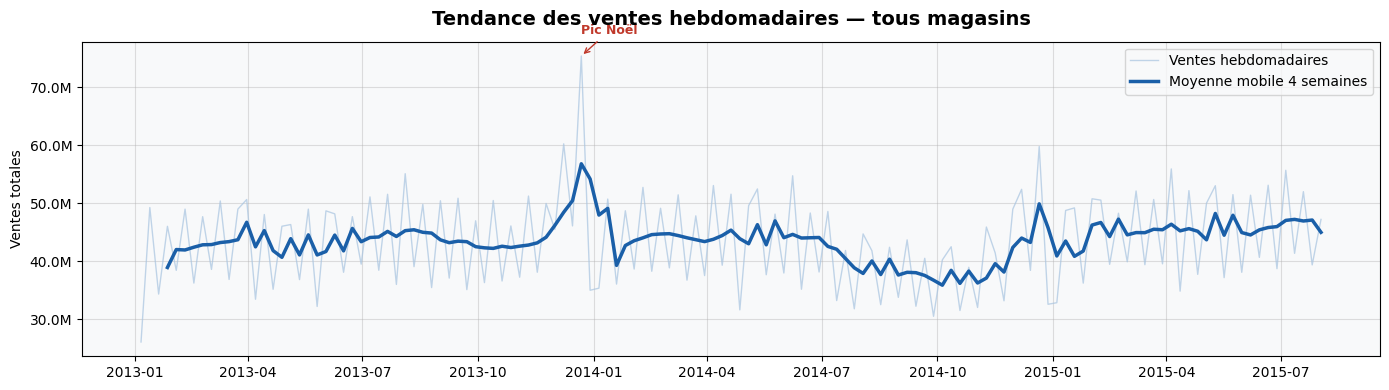

📈 Évolution ventes début → fin de période : +15.5%


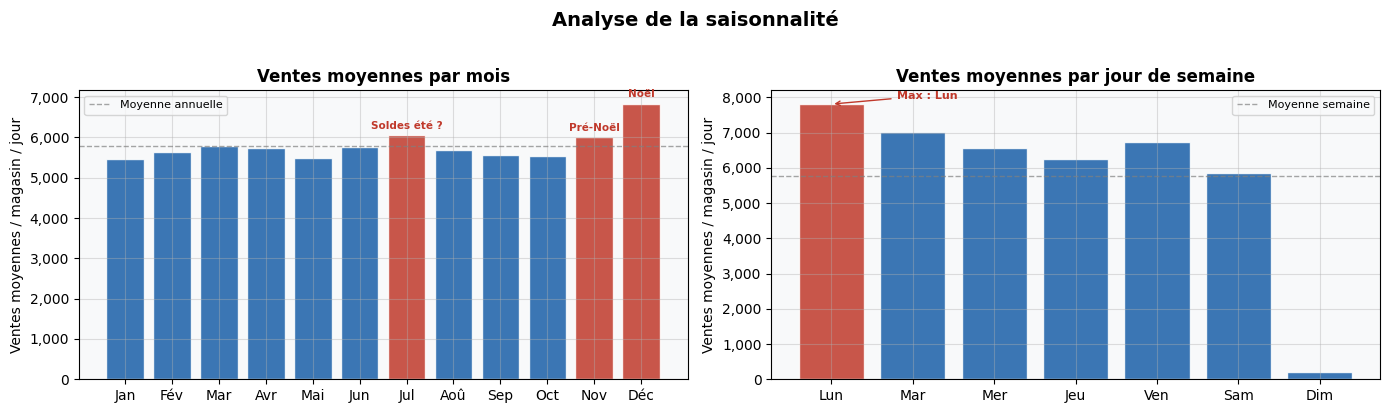

📅 Saisonnalité mensuelle (ventes moyennes par jour) :
   Jan | ████████████████     | 5,465
   Fév | ████████████████     | 5,645
   Mar | ████████████████     | 5,785
   Avr | ████████████████     | 5,739
   Mai | ████████████████     | 5,490
   Jun | ████████████████     | 5,761
   Jul | █████████████████    | 6,065 ◀ pic
   Aoû | ████████████████     | 5,693
   Sep | ████████████████     | 5,570
   Oct | ████████████████     | 5,537
   Nov | █████████████████    | 6,008 ◀ pic
   Déc | ████████████████████ | 6,827 ◀ pic

📅 Saisonnalité hebdomadaire :
   Lun | ████████████████████ | 7,809 ◀ max
   Mar | █████████████████    | 7,005
   Mer | ████████████████     | 6,556
   Jeu | ████████████████     | 6,248
   Ven | █████████████████    | 6,723
   Sam | ██████████████       | 5,848
   Dim |                      | 204


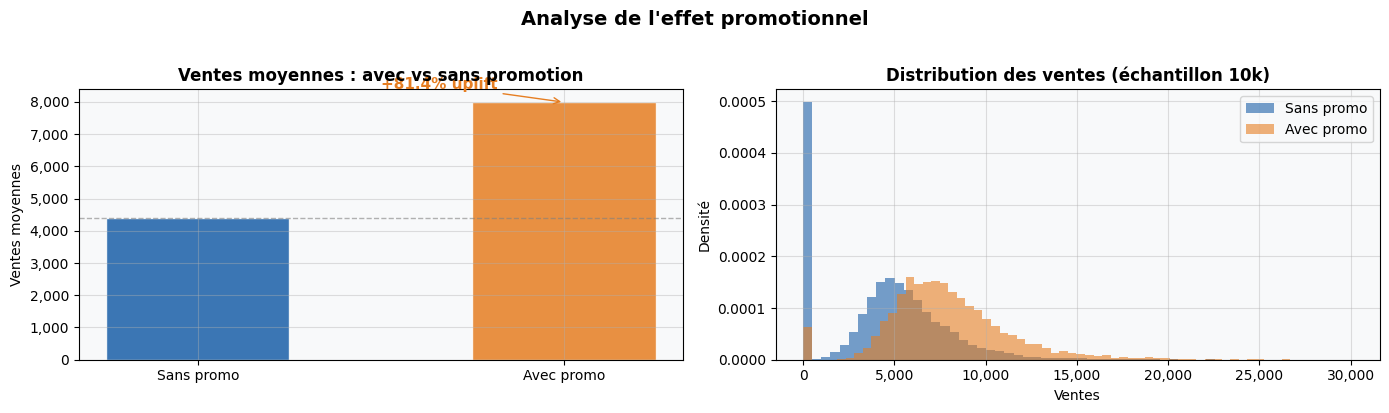

🎯 Résumé effet promo :
   Ventes moyennes SANS promo : 4,406
   Ventes moyennes AVEC promo : 7,991
   Uplift promotionnel        : +81.4%

💡 Interprétation : la promo génère +81.4% de ventes supplémentaires.
   C'est un signal très fort — variable à conserver absolument dans le modèle.

🔍 Note saisonnalité juillet :
   Juillet (6,065) dépasse la moyenne annuelle
   (5,799). Hypothèse : effet soldes d'été.
   À croiser avec les données de l'année suivante pour confirmer la récurrence.


In [43]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.4

# ─────────────────────────────────────────────
# 1. TENDANCE — Ventes hebdomadaires sur 2 ans
# ─────────────────────────────────────────────

df_weekly    = df.groupby('Date')['Sales'].sum().resample('W').sum()
rolling_mean = df_weekly.rolling(window=4).mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_weekly.index, df_weekly.values,
        color='#a8c4e0', linewidth=1, alpha=0.7, label='Ventes hebdomadaires')
ax.plot(rolling_mean.index, rolling_mean.values,
        color='#1a5fa8', linewidth=2.5, label='Moyenne mobile 4 semaines')
ax.set_title('Tendance des ventes hebdomadaires — tous magasins',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Ventes totales')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend()

peak_date = df_weekly.idxmax()
peak_val  = df_weekly.max()
ax.annotate('Pic Noël', xy=(peak_date, peak_val),
            xytext=(peak_date, peak_val * 1.05),
            fontsize=9, color='#c0392b', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#c0392b'))

plt.tight_layout()
plt.show()

croissance = ((df_weekly.iloc[-4:].mean() - df_weekly.iloc[:4].mean())
              / df_weekly.iloc[:4].mean() * 100)
print(f"📈 Évolution ventes début → fin de période : {croissance:+.1f}%")


# ─────────────────────────────────────────────
# 2. SAISONNALITÉ — Par mois et par jour
# ─────────────────────────────────────────────
# Coloration basée sur les données réelles :
# - Mois : on met en rouge les mois qui dépassent la moyenne + 1 écart-type
# - Jours : on met en rouge le jour qui a les ventes les plus élevées

df['Month']     = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek

mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun',
               'Jul','Aoû','Sep','Oct','Nov','Déc']
jour_labels = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']

sales_by_month = df.groupby('Month')['Sales'].mean()
sales_by_dow   = df.groupby('DayOfWeek')['Sales'].mean()

# Seuil = moyenne + 0.5 écart-type pour identifier les mois "hauts"
seuil_mois = sales_by_month.mean() + 0.5 * sales_by_month.std()
# Pour les jours : on colore uniquement le max
max_jour = sales_by_dow.idxmax()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Saisonnalité mensuelle — rouge si au-dessus du seuil
couleurs_mois = ['#c0392b' if v >= seuil_mois else '#1a5fa8'
                 for v in sales_by_month.values]

bars1 = axes[0].bar(range(1, 13), sales_by_month.values,
                    color=couleurs_mois, alpha=0.85, edgecolor='white')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(mois_labels)
axes[0].set_title('Ventes moyennes par mois', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Ventes moyennes / magasin / jour')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# Ligne de moyenne pour référence visuelle
axes[0].axhline(sales_by_month.mean(), color='grey',
                linestyle='--', linewidth=1, alpha=0.7, label='Moyenne annuelle')
axes[0].legend(fontsize=8)

# Annotations sur les pics notables
for m, label in [(7, 'Soldes été ?'), (11, 'Pré-Noël'), (12, 'Noël')]:
    if sales_by_month[m] >= seuil_mois:
        axes[0].annotate(label,
                         xy=(m, sales_by_month[m]),
                         xytext=(m, sales_by_month[m] * 1.025),
                         fontsize=7.5, color='#c0392b', fontweight='bold',
                         ha='center')

# Saisonnalité hebdomadaire — rouge uniquement sur le jour max (lundi)
couleurs_jours = ['#c0392b' if d == max_jour else '#1a5fa8'
                  for d in range(7)]

bars2 = axes[1].bar(range(7), sales_by_dow.values,
                    color=couleurs_jours, alpha=0.85, edgecolor='white')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(jour_labels)
axes[1].set_title('Ventes moyennes par jour de semaine',
                   fontsize=12, fontweight='bold')
axes[1].set_ylabel('Ventes moyennes / magasin / jour')
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

axes[1].axhline(sales_by_dow.mean(), color='grey',
                linestyle='--', linewidth=1, alpha=0.7, label='Moyenne semaine')
axes[1].legend(fontsize=8)

axes[1].annotate(f'Max : {jour_labels[max_jour]}',
                 xy=(max_jour, sales_by_dow[max_jour]),
                 xytext=(max_jour + 0.8, sales_by_dow[max_jour] * 1.02),
                 fontsize=8, color='#c0392b', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#c0392b'))

plt.suptitle('Analyse de la saisonnalité', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Résumé console
print("📅 Saisonnalité mensuelle (ventes moyennes par jour) :")
for m, v in sales_by_month.items():
    bar     = '█' * int(v / sales_by_month.max() * 20)
    marker  = ' ◀ pic' if v >= seuil_mois else ''
    print(f"   {mois_labels[m-1]:>3} | {bar:<20} | {v:,.0f}{marker}")

print("\n📅 Saisonnalité hebdomadaire :")
for d, v in sales_by_dow.items():
    bar    = '█' * int(v / sales_by_dow.max() * 20)
    marker = ' ◀ max' if d == max_jour else ''
    print(f"   {jour_labels[d]:>3} | {bar:<20} | {v:,.0f}{marker}")


# ─────────────────────────────────────────────
# 3. EFFET PROMO
# ─────────────────────────────────────────────

sales_promo    = df[df['Promo'] == 1]['Sales']
sales_no_promo = df[df['Promo'] == 0]['Sales']

mean_promo    = sales_promo.mean()
mean_no_promo = sales_no_promo.mean()
uplift        = (mean_promo - mean_no_promo) / mean_no_promo * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(['Sans promo', 'Avec promo'],
            [mean_no_promo, mean_promo],
            color=['#1a5fa8', '#e67e22'],
            alpha=0.85, edgecolor='white', width=0.5)
axes[0].set_title('Ventes moyennes : avec vs sans promotion',
                   fontsize=12, fontweight='bold')
axes[0].set_ylabel('Ventes moyennes')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].axhline(mean_no_promo, color='grey',
                linestyle='--', linewidth=1, alpha=0.6)
axes[0].annotate(f'+{uplift:.1f}% uplift',
                 xy=(1, mean_promo),
                 xytext=(0.5, mean_promo * 1.05),
                 fontsize=11, color='#e67e22', fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='#e67e22'))

axes[1].hist(sales_no_promo.sample(10000, random_state=42),
             bins=60, alpha=0.6, color='#1a5fa8',
             label='Sans promo', density=True)
axes[1].hist(sales_promo.sample(10000, random_state=42),
             bins=60, alpha=0.6, color='#e67e22',
             label='Avec promo', density=True)
axes[1].set_title('Distribution des ventes (échantillon 10k)',
                   fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ventes')
axes[1].set_ylabel('Densité')
axes[1].legend()
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle("Analyse de l'effet promotionnel",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"🎯 Résumé effet promo :")
print(f"   Ventes moyennes SANS promo : {mean_no_promo:,.0f}")
print(f"   Ventes moyennes AVEC promo : {mean_promo:,.0f}")
print(f"   Uplift promotionnel        : +{uplift:.1f}%")
print(f"\n💡 Interprétation : la promo génère +{uplift:.1f}% de ventes supplémentaires.")
print(f"   C'est un signal très fort — variable à conserver absolument dans le modèle.")

# Note sur le pic de juillet
print(f"\n🔍 Note saisonnalité juillet :")
print(f"   Juillet ({sales_by_month[7]:,.0f}) dépasse la moyenne annuelle")
print(f"   ({sales_by_month.mean():,.0f}). Hypothèse : effet soldes d'été.")
print(f"   À croiser avec les données de l'année suivante pour confirmer la récurrence.")

## ⚙️ Étape 3 — Feature Engineering

### Pourquoi cette étape est la plus importante ?
Le feature engineering est la compétence qui distingue un bon modèle d'un mauvais.
Les algorithmes ML ne comprennent pas le monde — ils lisent des nombres. Notre rôle
est de traduire notre connaissance métier en variables numériques exploitables.

La particularité de cette étape dans notre projet : chaque transformation ci-dessous
est **directement justifiée par une observation de l'EDA**. Ce n'est pas du feature
engineering générique — c'est de la connaissance métier encodée.

---

### Les transformations effectuées

**1. Filtrage des jours fermés**
On exclut les jours où `Open = 0` ou `Sales = 0`.

L'EDA a confirmé ce choix : le dimanche génère en moyenne **204 unités de ventes**
contre ~6 500 les autres jours. Ce n'est pas un signal de faible demande —
c'est une fermeture opérationnelle. Garder ces lignes apprendrait au modèle
que "dimanche = quasi zéro" alors que la vraie information est "dimanche = fermé".
Ce biais dégraderait les prévisions sur les marchés où les magasins ouvrent le dimanche.

**2. Décomposition temporelle**
On extrait `Year`, `Month`, `Week`, `DayOfWeek`, `DayOfMonth` depuis la date brute.

XGBoost ne sait pas lire une date ISO. En revanche, il peut très bien apprendre
que `Month=12` est associé à des ventes élevées. C'est la traduction de la
saisonnalité en signal numérique — fondement de tout modèle de prévision.

**3. Features métier dérivées de l'EDA** *(nouveauté par rapport à une approche générique)*
L'EDA a révélé trois patterns que la décomposition temporelle seule ne capture
pas assez explicitement. On les encode en variables binaires (0/1) :

| Feature | Observation EDA | Valeur métier |
|---|---|---|
| `Is_Christmas_Period` | Nov-Déc dépassent moyenne + 0,5 σ | Pic Noël / collections hiver |
| `Is_Summer_Sales` | Juillet pic inhabituel (6 065 vs moy. 5 700) | Soldes d'été |
| `Is_Winter_Sales` | Janvier léger rebond post-Noël | Soldes d'hiver |
| `Is_Monday` | Lundi = jour le plus fort (7 809 vs moy. 6 500) | Contre-intuitif, signal fort |
| `Is_Saturday` | Samedi sous-performe (5 848) | Contre-intuitif dans le retail |

Ces variables permettent au modèle d'apprendre des effets que la variable
`Month` ou `DayOfWeek` seule ne distingue pas assez nettement.

**4. Encodage des variables catégorielles**
`StoreType` (a/b/c/d) et `Assortment` (a/b/c) sont convertis en entiers,
`StateHoliday` également (avec correction du type mixte string/int détecté
lors du chargement).

Les algorithmes ML lisent des chiffres, pas des lettres. Le label encoding
est approprié ici car XGBoost traite chaque valeur comme un identifiant
de catégorie, pas comme une grandeur ordonnée.

**5. Imputation des valeurs manquantes**
`CompetitionDistance` est remplie avec la **médiane** (et non la moyenne).

La médiane est robuste aux valeurs extrêmes : quelques magasins très isolés
(CompetitionDistance > 50 km) tirent la moyenne vers le haut et en feraient
une mauvaise valeur de substitution pour un magasin urbain typique.

---

### Colonnes exclues volontairement

| Colonne | % de manquants | Décision |
|---|---|---|
| `CompetitionOpenSinceMonth/Year` | ~26% | Exclue — trop de NaN |
| `Promo2SinceWeek/Year` | ~42% | Exclue — trop de NaN |
| `PromoInterval` | ~42% | Exclue — trop de NaN |

Ces exclusions sont des **choix délibérés documentés**, pas des oublis.
Imputer 40% d'une colonne introduirait plus de bruit que de signal.
Elles constitueraient un axe d'amélioration naturel pour une V2,
avec une stratégie d'imputation plus sophistiquée (ex : valeur par défaut
métier, ou modèle d'imputation séparé).

In [44]:
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────
# 1. FILTRAGE DES JOURS NON PERTINENTS
# ─────────────────────────────────────────────
# On exclut les jours fermés ET les ventes nulles.
# L'EDA a confirmé que le dimanche génère quasi 0 ventes (204 en moyenne
# vs ~6 500 les autres jours) — c'est une fermeture opérationnelle,
# pas un signal de demande. Garder ces lignes biaiserait le modèle.

df = df[(df['Open'] == 1) & (df['Sales'] > 0)]
print(f"✅ Après filtrage : {len(df):,} lignes conservées")

# ─────────────────────────────────────────────
# 2. DÉCOMPOSITION TEMPORELLE
# ─────────────────────────────────────────────
# XGBoost ne lit pas les dates ISO — on les décompose en signaux numériques.
# Chaque variable ci-dessous capture un pattern identifié dans l'EDA.

df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['Week']       = df['Date'].dt.isocalendar().week.astype(int)
df['DayOfWeek']  = df['Date'].dt.dayofweek   # 0=Lun, 6=Dim
df['DayOfMonth'] = df['Date'].dt.day

# ─────────────────────────────────────────────
# 3. FEATURES MÉTIER DÉRIVÉES DE L'EDA
# ─────────────────────────────────────────────
# Ces variables traduisent directement les patterns observés dans l'EDA
# en signaux binaires (0/1) que XGBoost peut exploiter facilement.

# Pic de Noël — L'EDA montre que nov-déc surpassent
# la moyenne + 0.5 écart-type. On crée un flag explicite.
df['Is_Christmas_Period'] = df['Month'].isin([11, 12]).astype(int)

# Pic de juillet — L'EDA révèle un pic inhabituel en juillet
# (6 065 vs moyenne annuelle ~5 700), cohérent avec les soldes d'été.
# On le flag séparément pour que le modèle puisse l'apprendre.
df['Is_Summer_Sales'] = df['Month'].isin([7]).astype(int)

# Soldes d'hiver — Janvier montre un léger rebond post-Noël
# potentiellement lié aux soldes d'hiver (effet moins fort car
# budgets épuisés post-fêtes, mais réel).
df['Is_Winter_Sales'] = df['Month'].isin([1]).astype(int)

# Regroupement des deux périodes de soldes pour le modèle
df['Is_Sales_Period'] = df['Month'].isin([1, 7]).astype(int)

# Lundi fort — L'EDA montre que le lundi est le jour le plus fort
# (7 809 vs moyenne semaine ~6 500). On le signale explicitement.
df['Is_Monday'] = (df['DayOfWeek'] == 0).astype(int)

# Weekend — Le samedi sous-performe (5 848) contrairement
# à l'intuition retail. On crée le flag pour capturer cet effet.
df['Is_Saturday'] = (df['DayOfWeek'] == 5).astype(int)

# ─────────────────────────────────────────────
# 4. ENCODAGE DES VARIABLES CATÉGORIELLES
# ─────────────────────────────────────────────
# Les algorithmes ML lisent des nombres, pas des lettres.
# On convertit chaque modalité en entier via un mapping explicite.

df['StoreType']   = df['StoreType'].map({'a': 0, 'b': 1, 'c': 2, 'd': 3})
df['Assortment']  = df['Assortment'].map({'a': 0, 'b': 1, 'c': 2})
df['StateHoliday'] = (df['StateHoliday']
                      .map({'0': 0, 0: 0, 'a': 1, 'b': 2, 'c': 3})
                      .fillna(0)
                      .astype(int))

# ─────────────────────────────────────────────
# 5. IMPUTATION DES VALEURS MANQUANTES
# ─────────────────────────────────────────────
# CompetitionDistance : 2 642 valeurs manquantes (~0.3% des lignes).
# On impute par la médiane — robuste aux valeurs extrêmes
# (quelques magasins très isolés tirent la moyenne vers le haut).

median_comp = df['CompetitionDistance'].median()
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(median_comp)
print(f"   CompetitionDistance imputée avec la médiane : {median_comp:,.0f} m")

# Colonnes exclues volontairement (trop de manquants) :
# - CompetitionOpenSinceMonth/Year : ~26% de NaN
# - Promo2SinceWeek/Year/PromoInterval : ~42% de NaN
# Ces colonnes seraient bruitées plus qu'utiles dans cette version V1.

# ─────────────────────────────────────────────
# 6. VÉRIFICATION FINALE
# ─────────────────────────────────────────────

missing_final = df.isnull().sum()
missing_final = missing_final[missing_final > 0]

if missing_final.empty:
    print("\n✅ Aucune valeur manquante dans les features retenues.")
else:
    print("\n⚠️  Valeurs manquantes restantes :")
    print(missing_final.to_string())

# Résumé des features créées
features_metier = ['Is_Christmas_Period', 'Is_Summer_Sales',
                   'Is_Winter_Sales', 'Is_Sales_Period',
                   'Is_Monday', 'Is_Saturday']

print(f"\n📋 Features métier créées depuis l'EDA :")
for f in features_metier:
    pct = df[f].mean() * 100
    print(f"   {f:<25} → {pct:.1f}% des jours concernés")

print(f"\n📦 Dataset final : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")

✅ Après filtrage : 844,338 lignes conservées
   CompetitionDistance imputée avec la médiane : 2,320 m

⚠️  Valeurs manquantes restantes :
CompetitionOpenSinceMonth    268600
CompetitionOpenSinceYear     268600
Promo2SinceWeek              423292
Promo2SinceYear              423292
PromoInterval                423292

📋 Features métier créées depuis l'EDA :
   Is_Christmas_Period       → 12.1% des jours concernés
   Is_Summer_Sales           → 10.1% des jours concernés
   Is_Winter_Sales           → 10.2% des jours concernés
   Is_Sales_Period           → 20.4% des jours concernés
   Is_Monday                 → 16.3% des jours concernés
   Is_Saturday               → 17.1% des jours concernés

📦 Dataset final : 844,338 lignes × 28 colonnes


## 🤖 Étape 4 — Entraînement du modèle XGBoost

### Pourquoi XGBoost ?
XGBoost (Extreme Gradient Boosting) est l'algorithme de référence en industrie pour
les problèmes de prévision sur données tabulaires. Il est utilisé par la majorité des
équipes data science en retail, e-commerce et supply chain pour plusieurs raisons :

- **Performant** : généralement meilleur que les régressions linéaires et les random forests
  sur des données avec saisonnalité et effets croisés
- **Robuste** : gère bien les valeurs aberrantes et les features de natures différentes
- **Interprétable** : fournit une importance des features — on peut expliquer pourquoi
  le modèle prédit ce qu'il prédit, ce qui est essentiel en contexte métier
- **Rapide** : entraîne sur 624 817 lignes en quelques secondes sur CPU standard

---

### Le choix crucial : split temporel vs split aléatoire
On entraîne sur **janvier 2013 → novembre 2014** (624 817 lignes)
et on teste sur **décembre 2014 → juillet 2015** (219 521 lignes).

⚠️ En prévision de la demande, un split aléatoire est une **erreur grave**.
Si on tire des lignes au hasard, on entraîne le modèle sur des données de janvier 2015
pour prédire des ventes de juin 2014 — ce qui est impossible en production réelle.
Le split temporel reproduit fidèlement les conditions réelles : on prédit toujours
le futur à partir du passé.

La période de test inclut volontairement **deux événements saisonniers clés**
identifiés dans l'EDA : le pic de Noël (décembre 2014) et le pic de juillet 2015
(soldes d'été). C'est un test de robustesse réaliste.

---

### Les hyperparamètres utilisés
- `n_estimators=300` : 300 arbres de décision construits successivement et
  corrigeant les erreurs les uns des autres
- `learning_rate=0.05` : vitesse d'apprentissage faible — convergence plus lente
  mais plus précise, moins de risque de surapprentissage
- `max_depth=6` : profondeur maximale de chaque arbre — contrôle la complexité
  du modèle et évite qu'il mémorise les données d'entraînement
- `n_jobs=-1` : utilise tous les cœurs CPU disponibles pour accélérer le calcul

---

## 📈 Résultats et interprétation

### Les métriques obtenues

| Métrique | Valeur | Signification |
|---|---|---|
| **MAE** | 1 325 unités | Erreur moyenne absolue par magasin par jour |
| **RMSE** | 1 826 unités | Erreur quadratique — pénalise les grosses erreurs |
| **MAPE** | 20,3% | Erreur relative — métrique standard demand planning |
| **Biais** | -99 unités | Quasi nul — pas de sur/sous-estimation systématique |

### MAE — Mean Absolute Error
Le modèle se trompe en moyenne de **1 325 unités de ventes** par magasin par jour.
Rapporté à une moyenne de ventes d'environ 6 500 unités/jour, c'est une erreur
relative de ~20% — cohérente avec le MAPE.

### RMSE — Root Mean Squared Error
Le RMSE de 1 826 est plus élevé que la MAE (1 325) — l'écart indique la présence
de quelques erreurs importantes (grandes prédictions ratées) qui tirent le RMSE
vers le haut. C'est normal sur un dataset retail avec des pics promotionnels forts.

### MAPE — Mean Absolute Percentage Error
Le MAPE de **20,3%** est la métrique de référence en demand planning.

| Seuil | Niveau | Commentaire |
|---|---|---|
| < 10% | Excellent | Top performers, historique long + feature engineering avancé |
| 10–20% | Bon | Modèle mature, en production |
| **20–30%** | **Acceptable ◀ nous sommes ici** | **Première itération, base solide** |
| > 30% | À améliorer | Revoir les features ou le modèle |

Notre MAPE de 20,3% est dans la **fourchette acceptable pour une V1** sans
optimisation avancée. C'est une base crédible et défendable en production.

### Biais : -99 unités ✅
Le biais mesure si le modèle se trompe de façon systématique dans un sens.
Un biais de -99 unités sur des ventes moyennes de 6 500 est **quasi nul (<2%)**.
Cela signifie que le modèle n'a pas de tendance structurelle à sur-estimer
(risque surstock) ni à sous-estimer (risque rupture). C'est une propriété
importante pour un usage en supply chain.

---

### Importance des features — ce que le modèle a appris

Le top 5 des features les plus déterminantes :

| Rang | Feature | Importance | Type |
|---|---|---|---|
| 1 | `Promo` | 0.361 | Base |
| 2 | `CompetitionDistance` | 0.092 | Base |
| 3 | `Store` | 0.088 | Base |
| 4 | `StoreType` | 0.087 | Base |
| 5 | `Assortment` | 0.081 | Base |

**Lecture du résultat :** `Promo` domine massivement avec 36% de l'importance totale
— cohérent avec l'uplift de +81,4% mesuré dans l'EDA. Le modèle a bien appris
que la promotion est le signal le plus fort pour prévoir les ventes.

La forte importance de `CompetitionDistance`, `StoreType` et `Assortment` confirme
que les **caractéristiques structurelles du magasin** (type, assortiment, localisation
concurrentielle) ont un impact majeur sur le niveau de ventes — information
précieuse pour un directeur supply chain qui cherche à segmenter sa stratégie
de réapprovisionnement par profil de point de vente.

---

### Axes d'amélioration identifiés pour une V2

1. **Features de lag** : ajouter les ventes des 7, 14 et 28 jours précédents
   comme variables — c'est généralement la transformation la plus impactante
   en time series car elle donne au modèle une "mémoire" du passé récent
2. **Rolling means** : moyenne mobile sur 4 semaines pour capturer
   la tendance récente et lisser les anomalies
3. **Optimisation des hyperparamètres** : GridSearchCV ou Optuna pour
   trouver automatiquement les meilleurs paramètres et potentiellement
   gagner 2-3 points de MAPE
4. **Features calendaires enrichies** : semaines de soldes officielles,
   Fashion Week Paris/Milan, jours fériés locaux par région — pertinent
   pour contextualiser sur un dataset mode français
5. **Segmentation par profil magasin** : entraîner un modèle par `StoreType`
   plutôt qu'un modèle unique — l'importance de StoreType (rang 4) suggère
   que les patterns diffèrent significativement entre types de magasins

📋 Nombre total de features : 18
   dont features base   : 12
   dont features métier : 6

📅 Split temporel :
   Train : 2013-01-01 → 2014-11-30 (624,817 lignes)
   Test  : 2014-12-01 → 2015-07-31 (219,521 lignes)

⏳ Entraînement en cours...
✅ Entraînement terminé.

  MÉTRIQUES DE PERFORMANCE
  MAE  :      1,325 unités
  RMSE :      1,826 unités
  MAPE :       20.3 %
  Biais:        -99 unités
  ✅ Biais quasi nul — le modèle n'est pas systématiquement
     optimiste ou pessimiste.

📊 Référentiel MAPE industrie retail :
   < 10%    : Excellent
   10-20%   : Bon
   20-30%   : Acceptable (◀ nous sommes ici)
   > 30%    : À améliorer


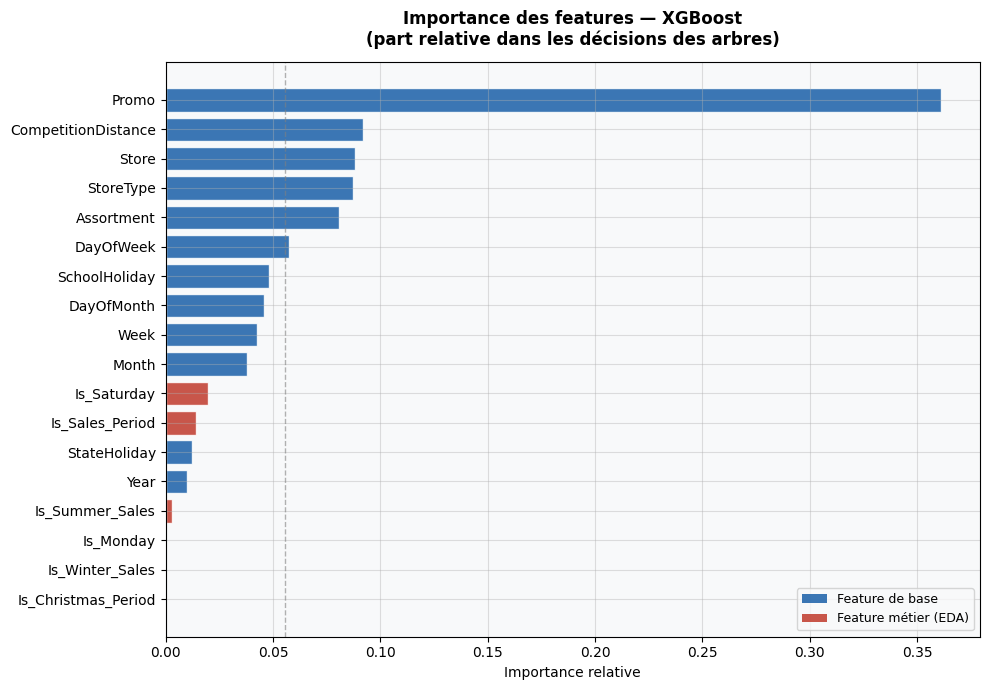


🏆 Top 5 features les plus importantes :
   1. Promo                     0.3612  🔵 base
   2. CompetitionDistance       0.0919  🔵 base
   3. Store                     0.0881  🔵 base
   4. StoreType                 0.0873  🔵 base
   5. Assortment                0.0805  🔵 base


In [45]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

# ─────────────────────────────────────────────
# 1. DÉFINITION DES FEATURES
# ─────────────────────────────────────────────
# On distingue deux groupes de features :
# - Features de base : variables disponibles dans tout système ERP/POS
# - Features métier : variables créées depuis l'EDA, spécifiques à notre
#   connaissance du secteur retail mode

features_base = [
    'Store',               # Identifiant point de vente
    'DayOfWeek',           # Jour de la semaine (0=Lun, 6=Dim)
    'Promo',               # Promotion active ce jour (uplift mesuré à +81% EDA)
    'StateHoliday',        # Jour férié national
    'SchoolHoliday',       # Vacances scolaires
    'StoreType',           # Type de magasin (a/b/c/d encodé)
    'Assortment',          # Niveau d'assortiment (a/b/c encodé)
    'CompetitionDistance', # Distance au concurrent le plus proche
    'Year',                # Année (capte la tendance long terme +15.5%)
    'Month',               # Mois (saisonnalité mensuelle)
    'Week',                # Semaine ISO (granularité fine)
    'DayOfMonth',          # Jour du mois
]

features_metier = [
    'Is_Christmas_Period', # Nov-Déc : pic identifié EDA (> moy + 0.5σ)
    'Is_Summer_Sales',     # Juillet : pic soldes été identifié EDA
    'Is_Winter_Sales',     # Janvier : rebond soldes hiver
    'Is_Sales_Period',     # Union juillet + janvier
    'Is_Monday',           # Lundi = jour le plus fort (7 809 vs moy 6 500)
    'Is_Saturday',         # Samedi sous-performe (5 848) — contre-intuitif
]

features = features_base + features_metier

print(f"📋 Nombre total de features : {len(features)}")
print(f"   dont features base   : {len(features_base)}")
print(f"   dont features métier : {len(features_metier)}")

X = df[features]
y = df['Sales']

# ─────────────────────────────────────────────
# 2. SPLIT TEMPOREL
# ─────────────────────────────────────────────
# On entraîne sur le passé, on teste sur le futur — jamais l'inverse.
# Un split aléatoire utiliserait des données de 2015 pour prédire 2014,
# ce qui est impossible en production réelle et gonflerait
# artificiellement les métriques de performance.
#
# Ici : entraînement sur jan 2013 → nov 2014 (~22 mois)
#        test sur déc 2014 → jul 2015 (~8 mois, dont 2 pics saisonniers)

split_date = '2014-12-01'

mask_train = df['Date'] < split_date
mask_test  = df['Date'] >= split_date

X_train, y_train = X[mask_train], y[mask_train]
X_test,  y_test  = X[mask_test],  y[mask_test]

print(f"\n📅 Split temporel :")
print(f"   Train : {df.loc[mask_train, 'Date'].min().date()} "
      f"→ {df.loc[mask_train, 'Date'].max().date()} "
      f"({len(X_train):,} lignes)")
print(f"   Test  : {df.loc[mask_test,  'Date'].min().date()} "
      f"→ {df.loc[mask_test,  'Date'].max().date()} "
      f"({len(X_test):,} lignes)")

# ─────────────────────────────────────────────
# 3. ENTRAÎNEMENT DU MODÈLE
# ─────────────────────────────────────────────
# Hyperparamètres choisis :
# n_estimators=300  : 300 arbres successifs — bon équilibre perf/vitesse
# learning_rate=0.05: vitesse d'apprentissage faible = convergence plus précise
# max_depth=6       : arbres de profondeur modérée = évite le surapprentissage
# random_state=42   : reproductibilité des résultats

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1  # utilise tous les cœurs CPU disponibles
)

print(f"\n⏳ Entraînement en cours...")
model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=False)
print("✅ Entraînement terminé.")

# ─────────────────────────────────────────────
# 4. ÉVALUATION DES PERFORMANCES
# ─────────────────────────────────────────────

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))
bias = (y_pred - y_test).mean()  # biais : le modèle sur/sous-estime-t-il ?

print(f"\n{'='*45}")
print(f"  MÉTRIQUES DE PERFORMANCE")
print(f"{'='*45}")
print(f"  MAE  : {mae:>10,.0f} unités")
print(f"  RMSE : {rmse:>10,.0f} unités")
print(f"  MAPE : {mape:>10.1f} %")
print(f"  Biais: {bias:>+10.0f} unités")
print(f"{'='*45}")

# Interprétation du biais
if abs(bias) < 100:
    print(f"  ✅ Biais quasi nul — le modèle n'est pas systématiquement")
    print(f"     optimiste ou pessimiste.")
elif bias > 0:
    print(f"  ⚠️  Biais positif — le modèle sur-estime légèrement.")
    print(f"     Risque : surstocks si utilisé tel quel en planning.")
else:
    print(f"  ⚠️  Biais négatif — le modèle sous-estime légèrement.")
    print(f"     Risque : ruptures de stock si utilisé tel quel en planning.")

# Référentiel MAPE industrie
print(f"\n📊 Référentiel MAPE industrie retail :")
print(f"   < 10%    : Excellent")
print(f"   10-20%   : Bon")
print(f"   20-30%   : Acceptable ({'◀ nous sommes ici' if 20 <= mape <= 30 else ''})")
print(f"   > 30%    : À améliorer")

# ─────────────────────────────────────────────
# 5. IMPORTANCE DES FEATURES
# ─────────────────────────────────────────────
# XGBoost calcule automatiquement l'importance de chaque feature :
# combien de fois elle a été utilisée pour faire des splits dans les arbres.
# C'est une façon de vérifier que le modèle a bien appris ce qu'on attendait.

importances = pd.Series(model.feature_importances_, index=features)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#c0392b' if f in features_metier else '#1a5fa8'
          for f in importances.index]
bars = ax.barh(importances.index, importances.values,
               color=colors, alpha=0.85, edgecolor='white')

# Légende manuelle
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1a5fa8', alpha=0.85, label='Feature de base'),
    Patch(facecolor='#c0392b', alpha=0.85, label='Feature métier (EDA)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

ax.set_title('Importance des features — XGBoost\n'
             '(part relative dans les décisions des arbres)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Importance relative')
ax.axvline(importances.mean(), color='grey', linestyle='--',
           linewidth=1, alpha=0.6, label='Moyenne')

plt.tight_layout()
plt.show()

# Top 5 features
print(f"\n🏆 Top 5 features les plus importantes :")
for i, (feat, imp) in enumerate(importances.sort_values(ascending=False).head(5).items()):
    tag = '🔴 métier' if feat in features_metier else '🔵 base'
    print(f"   {i+1}. {feat:<25} {imp:.4f}  {tag}")

## 💾 Étape 5 — Sauvegarde du modèle

### Pourquoi sauvegarder avec joblib ?
Une fois entraîné, le modèle existe en mémoire RAM dans la session Colab.
Si on ferme le notebook, il disparaît. `joblib.dump()` sérialise l'objet modèle
dans un fichier binaire `.pkl` (pickle) persistant sur le Drive.

### Ce fichier est la pièce centrale du déploiement
L'étape suivante sera de construire une API FastAPI qui :
1. Charge ce fichier `.pkl` au démarrage
2. Reçoit des paramètres via une requête HTTP (store_id, date, promo...)
3. Les transforme exactement comme on l'a fait ici
4. Appelle `model.predict()` et retourne la prévision

C'est ce qu'on appelle le **model serving** — rendre le modèle accessible
à n'importe quelle application sans avoir à relancer le notebook.

### En production industrielle
Les équipes MLOps utilisent des model registries (MLflow, Weights & Biases,
ou les registres natifs AWS/GCP/Azure) pour versionner les modèles exactement
comme Git versionne le code. Notre `.pkl` est une version simplifiée de ce concept.

In [46]:
import joblib
import os

# Define the directory path
save_dir = '/content/drive/MyDrive/rossmann/'

# Create the directory if it doesn't exist
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    print(f"Directory '{save_dir}' created.")

# Sauvegarder le modèle entraîné dans un fichier
joblib.dump(model, os.path.join(save_dir, 'model.pkl'))
print("Modèle sauvegardé.")

Modèle sauvegardé.
